In [1]:
# ============================================================
# DECISION TREE CLASSIFICATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    "Attendance": [50, 55, 60, 65, 70,
                   75, 80, 85, 90, 95],

    "Result": ["Fail", "Fail", "Fail", "Fail", "Fail",
               "Pass", "Pass", "Pass", "Pass", "Pass"]
}

df = pd.DataFrame(data)

print(df)

   Study_Hours  Attendance Result
0            1          50   Fail
1            2          55   Fail
2            3          60   Fail
3            4          65   Fail
4            5          70   Fail
5            6          75   Pass
6            7          80   Pass
7            8          85   Pass
8            9          90   Pass
9           10          95   Pass


In [2]:
# ============================================================
# Calculate Entropy
# ============================================================

def entropy(labels):

    # Count each class
    values, counts = np.unique(labels, return_counts=True)

    probabilities = counts / len(labels)

    entropy_value = 0

    for p in probabilities:

        if p > 0:
            entropy_value -= p * np.log2(p)

    return entropy_value


# Entropy of complete dataset

H = entropy(df["Result"])

print("Entropy of Dataset =", round(H, 4))

Entropy of Dataset = 1.0


In [3]:
# ============================================================
# Entropy Examples
# ============================================================

all_pass = ["Pass", "Pass", "Pass", "Pass", "Pass"]

all_fail = ["Fail", "Fail", "Fail", "Fail", "Fail"]

mixed = ["Pass", "Pass", "Fail", "Fail", "Pass"]

print("Entropy of all Pass =",
      entropy(all_pass))

print("Entropy of all Fail =",
      entropy(all_fail))

print("Entropy of mixed data =",
      entropy(mixed))

Entropy of all Pass = 0.0
Entropy of all Fail = 0.0
Entropy of mixed data = 0.9709505944546686


In [4]:
# ============================================================
# Information Gain
# ============================================================

def information_gain(parent, left_child, right_child):

    parent_entropy = entropy(parent)

    left_entropy = entropy(left_child)
    right_entropy = entropy(right_child)

    n = len(parent)

    n_left = len(left_child)
    n_right = len(right_child)

    weighted_entropy = (
        (n_left / n) * left_entropy
        +
        (n_right / n) * right_entropy
    )

    gain = parent_entropy - weighted_entropy

    return gain

In [5]:
# ============================================================
# Test a Split
# ============================================================

left = df[df["Study_Hours"] <= 5]["Result"]

right = df[df["Study_Hours"] > 5]["Result"]

print("Left Node:")
print(left.values)

print("\nRight Node:")
print(right.values)

gain = information_gain(
    df["Result"],
    left,
    right
)

print("\nInformation Gain =",
      round(gain, 4))

Left Node:
['Fail' 'Fail' 'Fail' 'Fail' 'Fail']

Right Node:
['Pass' 'Pass' 'Pass' 'Pass' 'Pass']

Information Gain = 1.0


In [6]:
# ============================================================
# Find Best Study-Hour Split
# ============================================================

best_gain = -1
best_threshold = None

for threshold in df["Study_Hours"].unique():

    left = df[
        df["Study_Hours"] <= threshold
    ]["Result"]

    right = df[
        df["Study_Hours"] > threshold
    ]["Result"]

    # Ignore empty groups
    if len(left) == 0 or len(right) == 0:
        continue

    gain = information_gain(
        df["Result"],
        left,
        right
    )

    print(
        "Threshold:",
        threshold,
        " Information Gain:",
        round(gain, 4)
    )

    if gain > best_gain:

        best_gain = gain
        best_threshold = threshold


print("\nBest Threshold =", best_threshold)
print("Best Information Gain =",
      round(best_gain, 4))

Threshold: 1  Information Gain: 0.108
Threshold: 2  Information Gain: 0.2365
Threshold: 3  Information Gain: 0.3958
Threshold: 4  Information Gain: 0.61
Threshold: 5  Information Gain: 1.0
Threshold: 6  Information Gain: 0.61
Threshold: 7  Information Gain: 0.3958
Threshold: 8  Information Gain: 0.2365
Threshold: 9  Information Gain: 0.108

Best Threshold = 5
Best Information Gain = 1.0


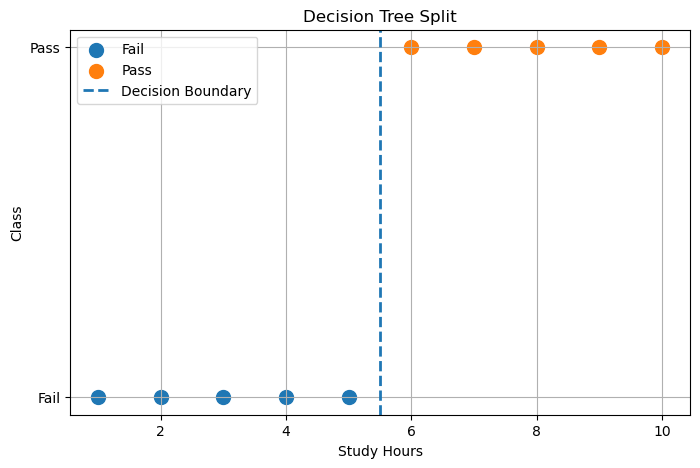

In [7]:
# ============================================================
# Visualize the Decision
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df[df["Result"] == "Fail"]["Study_Hours"],
    np.zeros(5),
    s=100,
    label="Fail"
)

plt.scatter(
    df[df["Result"] == "Pass"]["Study_Hours"],
    np.ones(5),
    s=100,
    label="Pass"
)

plt.axvline(
    best_threshold + 0.5,
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Study Hours")
plt.ylabel("Class")

plt.yticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.title("Decision Tree Split")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
# ============================================================
# Decision Tree Prediction
# ============================================================

def predict_student(study_hours):

    if study_hours <= best_threshold:
        return "Fail"

    else:
        return "Pass"


# Test new students

new_students = [2, 4, 5, 6, 8, 10]

print("Predictions\n")

for hours in new_students:

    prediction = predict_student(hours)

    print(
        "Study Hours =",
        hours,
        "→",
        prediction
    )

Predictions

Study Hours = 2 → Fail
Study Hours = 4 → Fail
Study Hours = 5 → Fail
Study Hours = 6 → Pass
Study Hours = 8 → Pass
Study Hours = 10 → Pass


In [9]:
# ============================================================
# Display Decision Tree
# ============================================================

print("""
                 Study Hours
                /            \\
             <= 5             > 5
              /                 \\
           FAIL                PASS
""")


                 Study Hours
                /            \
             <= 5             > 5
              /                 \
           FAIL                PASS

